In [65]:
%cd /depot/bingxin/data/env/data_test

/depot/bingxin/data/env/data_test


In [66]:
!pwd

/depot/bingxin/data/env/data_test


In [67]:
import numpy as np
import csv, os
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import math
import mpmath as mp
from mpmath import mpf, exp, findroot, almosteq
from collections import Counter
warnings.filterwarnings("ignore", category=RuntimeWarning)
import time
import sys
from fractions import Fraction

def format_func(value, tick_number):
    if value < 10:
        return f"{value:.2f}"
    elif value < 100:
        return f"{value:.1f}"
    else:
        return f"{int(value)}"

start_time = time.time()

############# Precision #############
accuracy = 30
mp.dps = accuracy
mp.mp.dps = 30

In [68]:
## Test Machine Error

s = 1.0

for k in range(1, 101):
    s /= 2.0
    if (1.0 + s) <= 1.0:
        s *= 2.0
        print('Machine Epsilon by default (not privacy budget):', f"k={k-1}, eps={s}")
        break

s = mp.mpf('1.0')

for k in range(1, 1001):
    s /= mp.mpf('2.0')
    if (mp.mpf('1.0') + s) <= mp.mpf('1.0'):
        s *= mp.mpf('2.0')
        print('Machine Epsilon by mpmath (not privacy budget):', f"k={k-1}, eps={s}")
        break

Machine Epsilon by default (not privacy budget): k=52, eps=2.220446049250313e-16
Machine Epsilon by mpmath (not privacy budget): k=102, eps=1.97215226305252951352932141321e-31


In [69]:
## one record may change from path_num_1 to path_num_2 due to the choice of sensitivity
path_num_1 = 13
path_num_2 = 13

In [70]:
## Preparation

### Parameters
zero = mp.mpf('0')
one = mp.mpf('1')
two = mp.mpf('2')
three = mp.mpf('3')
four = mp.mpf('4')
five = mp.mpf('5')
six = mp.mpf('6')
seven = mp.mpf('7')
eight = mp.mpf('8')
nine = mp.mpf('9')

ten = mp.mpf('10')
eleven = mp.mpf('11')
twelve = mp.mpf('12')
thirteen = mp.mpf('13')
fourteen = mp.mpf('14')
fifteen = mp.mpf('15')
sixteen = mp.mpf('16')
seventeen = mp.mpf('17')
eighteen = mp.mpf('18')
nineteen = mp.mpf('19')

twenty = mp.mpf('20')
twenty_one = mp.mpf('21')
twenty_two = mp.mpf('22')
twenty_three = mp.mpf('23')
twenty_four = mp.mpf('24')
twenty_five = mp.mpf('25')
twenty_six = mp.mpf('26')
twenty_seven = mp.mpf('27')
twenty_eight = mp.mpf('28')
twenty_nine = mp.mpf('29')

thirty_two = mp.mpf('32')
forty_five = mp.mpf('45')
sixty_four = mp.mpf('64')
two_over_45 = two / forty_five


ten = mp.mpf('10')
hundred = mp.mpf('100')
one_fifty = mp.mpf('150')
thousand = mp.mpf('1000')

def float_to_mpf(x):
    return mp.mpf(x)

def fraction_to_mpf(frac):
    """Convert a Fraction to an mpmath.mpf with high precision."""
    num = mp.mpf(frac.numerator)
    denom = mp.mpf(frac.denominator)
    return num / denom

In [71]:
### read allocation path
file_path_1 = f"allocation_path/dhc_allocation_path_{path_num_1}.csv"
df_1 = pd.read_csv(file_path_1)

allocation_run_1 = []
for col in df_1.columns:
    allocation_run_1.extend(df_1[col].tolist())

file_path_2 = f"allocation_path/dhc_allocation_path_{path_num_2}.csv"
df_2 = pd.read_csv(file_path_2)

allocation_run_2 = []
for col in df_2.columns:
    allocation_run_2.extend(df_2[col].tolist())

allocation_run = [entry for entry in allocation_run_1 if entry != '0/1'] + \
                 [entry for entry in allocation_run_2 if entry != '0/1']

allocation_run[:22], len(allocation_run)

from fractions import Fraction

allocation_run_sorted = sorted(
    allocation_run,
    key=lambda x: Fraction(x.strip("'"))
)

allocation_run = allocation_run_sorted
allocation_run[:22], len(allocation_run)


rho_1 = [Fraction(s) for s in allocation_run_1]
rho_2 = [Fraction(s) for s in allocation_run_2]
if rho_1 != rho_2:
    print("Incorrect Allocations")

In [72]:
## Determine Parameters

### Delta

Delta = mp.mpf('1e-25')

### rho

rho_path = [Fraction(s) for s in allocation_run]
rho = sum(rho_path)/2

### sigma2_list

sigma2_list = [1/val for val in rho_path]

### psi2

psi2 = 1/rho

### a_list

a_list = [val / rho for val in rho_path]

### L

# Extract the denominators of all percentage
denominators = [frac.denominator for frac in a_list]
numerators = [frac.numerator for frac in a_list]

# Compute LCM of all denominators using math.lcm
lcm_value = math.lcm(*denominators)
gcd_value = math.gcd(*numerators)

L = Fraction(lcm_value, gcd_value)

a_list_L = [val * L for val in a_list]
# print(a_list_L)

### m

m = len(a_list)

### convert to numerical

rho = fraction_to_mpf(rho)
a_list = [fraction_to_mpf(frac) for frac in a_list]
a_list_L = [fraction_to_mpf(frac) for frac in a_list_L]
m = float_to_mpf(m)
L = fraction_to_mpf(L)
psi2 = fraction_to_mpf(psi2)
sigma2_list = [fraction_to_mpf(frac) for frac in sigma2_list]

print("tolerance:", Delta, "rho", rho, "L:", L)

tolerance: 1.0e-25 rho 4.9622 L: 49622.0


In [73]:
# Numerical Computation

### U

summ = mp.mpf('0')
for i in range(len(a_list)):
    summ += a_list[i]**2 * sigma2_list[i]

U = mp.ceil( L * mp.sqrt(- two * summ * mp.log(Delta / eight)) )

# optional only for nice expression of U, Find the smallest multiple of 100000 greater than U
step = mp.mpf('250000')
U = step * mp.ceil(U / step)

print(f"U must be larger than", U)

### N

summ = mp.mpf('0')
for i in range(len(a_list_L)):
    summ += a_list[i]**2 * sigma2_list[i]
log_term = mp.sqrt( - two  * summ * mp.log(Delta / eight) )

# ==== Final RHS expression ====
N = mp.ceil( U + L * log_term )

step = mp.mpf('250000')
N = step * mp.ceil(N / step)

print(f"N must be larger than", N)


U must be larger than 500000.0
N must be larger than 1000000.0


In [74]:
## Characteristic Functions

# Step 1: Get unique sigma2 values and their first occurrence indices
sigma2_index_map = {}
sigma2_unique_list = []
index_unique_list = []

for idx, sigma2 in enumerate(sigma2_list):
    if sigma2 not in sigma2_index_map:
        sigma2_index_map[sigma2] = len(sigma2_unique_list)
        sigma2_unique_list.append(sigma2)
        index_unique_list.append(idx)

# Step 2: Count appearances of each unique sigma2 value
appearance_counter = Counter(sigma2_list)
appearance_list = [appearance_counter[sigma2] for sigma2 in sigma2_unique_list]


print(appearance_counter)
print()
print(appearance_list)

Counter({mpf('20.9205020920502092050209205020916'): 36, mpf('909.090909090909090909090909090937'): 20, mpf('23.2558139534883720930232558139527'): 20, mpf('136.986301369863013698630136986312'): 18, mpf('10.0100100100100100100100100100103'): 18, mpf('32.2580645161290322580645161290321'): 16, mpf('11.5207373271889400921658986175121'): 16, mpf('8.06451612903225806451612903225801'): 4, mpf('5.2301255230125523012552301255229'): 4, mpf('2.88018433179723502304147465437803'): 4, mpf('34.2465753424657534246575342465781'): 2, mpf('2.50250250250250250250250250250258'): 2})

[20, 18, 2, 16, 20, 36, 16, 18, 4, 4, 4, 2]


In [75]:
############# Characteristic Functions #############
def char_func_num(sigma_i2, a_i_L, zeta):
    # Precompute constants
    trunc = int(mp.ceil(twenty_four * two * sigma_i2) + one)

    denom_coeff = one / (two * sigma_i2)

    # Numerator sum
    numerator = one
    for x in range(1, trunc + 1):
        x_mpf = mp.mpf(x)
        numerator += two * mp.cos(a_i_L * zeta * x_mpf) * mp.exp(-x_mpf**2 * denom_coeff)

    return numerator


def char_func_num_prod(zeta):
    product = mp.mpf("1.0")
    for i in range(len(sigma2_unique_list)):
        sigma_i2 = sigma2_unique_list[i]
        a_i_L = a_list_L[index_unique_list[i]]
        char_val = char_func_num(sigma_i2, a_i_L, zeta)
        product *= char_val ** appearance_list[i]

    return product


char_func_denom_prod = char_func_num_prod(zero)


def char_func_values(zeta):
    values = []
    for i in range(len(sigma2_unique_list)):
        sigma_i2 = sigma2_unique_list[i]
        a_i_L = a_list_L[index_unique_list[i]]
        char_num_val = char_func_num(sigma_i2, a_i_L, zeta)
        char_denom_val = char_func_num(sigma_i2, a_i_L, zero)
        values.append( (char_num_val / char_denom_val) ** appearance_list[i] )

    return values


############# Weight Function #############
def weight_first(zeta, t_0, L):
    lower_1 = mp.ceil(t_0 * L)
    stable_cut = Delta
    if abs(zeta) >= stable_cut:
        first = mp.cos(lower_1 * zeta) + mp.cos(U * zeta)
        factor = mp.cos(zeta / two) / mp.sin(zeta / two)
        second = mp.sin(U * zeta) - mp.sin(lower_1 * zeta)
        return (one / two) * (one / mp.pi) * (first + factor * second)

    elif 0 < abs(zeta) < stable_cut:
        first = mp.cos(lower_1 * zeta) + mp.cos(U * zeta)
        factor = mp.cos(zeta / two) / (zeta / two)
        second = mp.sin(U * zeta) - mp.sin(lower_1 * zeta)
        return (one / two) * (one / mp.pi) * (first + factor * second)

    else:
        return (one / mp.pi) * (U - lower_1 + one)

def weight_second(zeta, T_0, L):
    lower_2 = mp.ceil(T_0 * L)
    stable_cut = Delta
    if abs(zeta) >= stable_cut:
        first = mp.cos(lower_2 * zeta) + mp.cos(U * zeta)
        factor = mp.cos(zeta / two) / mp.sin(zeta / two)
        second = mp.sin(U * zeta) - mp.sin(lower_2 * zeta)
        return (one / two) * (one / mp.pi) * (first + factor * second)

    elif 0 < abs(zeta) < stable_cut:
        first = mp.cos(lower_2 * zeta) + mp.cos(U * zeta)
        factor = mp.cos(zeta / two) / (zeta / two)
        second = mp.sin(U * zeta) - mp.sin(lower_2 * zeta)
        return (one / two) * (one / mp.pi) * (first + factor * second)

    else:
        return (one / mp.pi) * (U - lower_2 + one)

In [76]:
## Determine Threshold

results = []  # Initialize a list to store results

for i in range(len(sigma2_unique_list)):
    sigma_i2 = sigma2_unique_list[i]
    a_i_L = a_list_L[index_unique_list[i]]

    half_period = mp.pi / a_i_L
    zeta_list = np.linspace(0, 1, 10000) * half_period

    # Calculate char_denom_val once outside the loop for efficiency
    char_denom_val = char_func_num(sigma_i2, a_i_L, zero)

    for zeta in zeta_list:
        zeta_mpf = mp.mpf(zeta)

        char_num_val = char_func_num(sigma_i2, a_i_L, zeta_mpf)

        char_single = (char_num_val / char_denom_val) ** appearance_list[i]

        # Check stopping criterion
        if char_single < Delta/U:
            # Use formatted string for clearer output
            result_dict = {
                "sigma2": sigma_i2,
                "a_i_L": a_i_L,
                "zeta": zeta,
                "char_single": char_single
            }

            results.append(result_dict)

            # Print nicely formatted message
            print(f"Stopped at sigma2: {result_dict['sigma2']}, "
                  f"a_i_L: {result_dict['a_i_L']}, "
                  f"zeta: {result_dict['zeta']}, "
                  f"char_single: {result_dict['char_single']}")

            break  # break inner loop upon condition met

# Save the results to CSV for later analysis
df_results = pd.DataFrame(results)
df_results.to_csv(f'results_DHC_v0/trade_off_curve/tmp/char_func_half_period_threshold_path_{path_num_1}_to_{path_num_2}.csv', index=False)


Stopped at sigma2: 909.090909090909090909090909091, a_i_L: 11.0, zeta: 0.00802614384764596358964085482378, char_single: 1.68077385174751633587962258149e-31
Stopped at sigma2: 136.986301369863013698630136986, a_i_L: 73.0, zeta: 0.0032839382495633294436058698196, char_single: 1.69488107780893296246266285609e-31
Stopped at sigma2: 34.2465753424657534246575342466, a_i_L: 292.0, zeta: 0.00492052739687192155127819482389, char_single: 1.9784139370030612954241899862e-31
Stopped at sigma2: 32.258064516129032258064516129, a_i_L: 310.0, zeta: 0.00168852154921317798708693572483, char_single: 1.95958620942784217065349020948e-31
Stopped at sigma2: 23.255813953488372093023255814, a_i_L: 430.0, zeta: 0.00128233639807005989745119547804, char_single: 1.95719525638883244460256217312e-31
Stopped at sigma2: 20.9205020920502092050209205021, a_i_L: 478.0, zeta: 0.00090642040549250012333633475639, char_single: 1.99341677012666981696166003927e-31
Stopped at sigma2: 11.5207373271889400921658986175, a_i_L: 868.0

In [77]:
# Load previously computed data
df_results = pd.read_csv(f'results_DHC_v0/trade_off_curve/tmp/char_func_half_period_threshold_path_{path_num_1}_to_{path_num_2}.csv')

# Ensure sigma2 values are precisely handled as mpf
df_results['sigma2'] = df_results['sigma2'].apply(mp.mpf)
df_results['zeta'] = df_results['zeta'].apply(mp.mpf)

midpoints = {}
zeta_interval = {}

for i in range(len(sigma2_unique_list)):
    sigma_i2 = sigma2_unique_list[i]
    a_i_L = a_list_L[index_unique_list[i]]
    half_period = mp.pi / a_i_L

    # Check presence with full precision
    matched_rows = df_results[df_results['a_i_L'] == int(a_i_L)]

    if matched_rows.empty:
        print(f"{sigma_i2} is not part of thresholding.")
        continue  # Skip if sigma_i2 not found

    print(f"Processing sigma2: {sigma_i2}, a_i_L: {a_i_L}")

    zeta_val = matched_rows['zeta'].iloc[0]

    # Step 1: Compute midpoints array
    two_pi_over_a = two * mp.pi / a_i_L
    midpoint = [two_pi_over_a * mp.mpf(j) for j in range(int(mp.floor(a_i_L)) + 1)]

    # Step 2: Keep only midpoints in [0, π]
    filtered_midpoints = [x for x in midpoint if zero <= x <= mp.pi]
    midpoints[i] = filtered_midpoints

    # Save zeta
    zeta_interval[i] = zeta_val

# Step 1: Sort the midpoints by the length of their value list
sorted_keys = sorted(midpoints.keys(), key=lambda k: len(midpoints[k]))

# Step 2: Reconstruct midpoints and zeta_interval with sorted keys
midpoints_sorted = {new_idx: midpoints[k] for new_idx, k in enumerate(sorted_keys)}
zeta_interval_sorted = {new_idx: zeta_interval[k] for new_idx, k in enumerate(sorted_keys)}

# overwrite the originals
midpoints = midpoints_sorted
zeta_interval = zeta_interval_sorted

# Number of intervals
n_intervals = int(N)
print("Number of intervals:", n_intervals)

# Output CSV path
csv_path = f"results_DHC_v0/trade_off_curve/threshold/char_fnc_threshold_point_path_{path_num_1}_to_{path_num_2}.csv"

# Open CSV and write header
with open(csv_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['zeta'])  # header

    for idx in range(n_intervals):
        i = mp.mpf(idx)
        zeta = two * mp.pi * i / n_intervals

        # Check for each j
        passed_all_j = True
        for j in midpoints:
            midpoint_list = midpoints[j]
            zeta_thresh = zeta_interval[j]

            # Find the closest midpoint to zeta
            closest = min(midpoint_list, key=lambda x: abs(x - zeta))

            # Check if abs(zeta - closest) < zeta_thresh
            if abs(zeta - closest) >= zeta_thresh:
                passed_all_j = False
                break  # early exit if any j fails

        if passed_all_j:
            writer.writerow([str(zeta)])  # only write valid zeta



Processing sigma2: 909.090909090909090909090909091, a_i_L: 11.0
Processing sigma2: 136.986301369863013698630136986, a_i_L: 73.0
Processing sigma2: 34.2465753424657534246575342466, a_i_L: 292.0
Processing sigma2: 32.258064516129032258064516129, a_i_L: 310.0
Processing sigma2: 23.255813953488372093023255814, a_i_L: 430.0
Processing sigma2: 20.9205020920502092050209205021, a_i_L: 478.0
Processing sigma2: 11.5207373271889400921658986175, a_i_L: 868.0
Processing sigma2: 10.01001001001001001001001001, a_i_L: 999.0
Processing sigma2: 8.06451612903225806451612903226, a_i_L: 1240.0
Processing sigma2: 5.23012552301255230125523012552, a_i_L: 1912.0
2.88018433179723502304147465438 is not part of thresholding.
2.5025025025025025025025025025 is not part of thresholding.
Number of intervals: 1000000


In [78]:
############# Integrant #############
def char_first(zeta):
    return char_func_num_prod(zeta) / char_func_denom_prod  # one/two here because even extension

def char_second(zeta):
    return char_func_num_prod(zeta) / char_func_denom_prod

In [79]:
n_intervals = int(N)
print("Number of intervals:", n_intervals)

# Input and output paths
input_csv = f"results_DHC_v0/trade_off_curve/threshold/char_fnc_threshold_point_path_{path_num_1}_to_{path_num_2}.csv"
output_csv = f"results_DHC_v0/trade_off_curve/char_fnc_eval/char_fnc_eval_path_{path_num_1}_to_{path_num_2}.csv"


# Step 1: Read all zeta values
zeta_list = []
with open(input_csv, mode='r') as infile:
    reader = csv.reader(infile)
    next(reader)  # skip header
    for row in reader:
        zeta_list.append(mp.mpf(row[0]))

# Step 3: Write result row by row with zeta, increment, cumulative sum
with open(output_csv, mode='w', newline='') as outfile:
    writer = csv.writer(outfile)
    writer.writerow(['zeta', 'char_fnc'])  # header

    for zeta in zeta_list:
        print("zeta:", zeta)
        char = char_first(zeta)
        print("char_fnc:", char)
        writer.writerow([str(zeta), str(char)])
        print("*"*45)


Number of intervals: 1000000
zeta: 0.0
char_fnc: 1.0
*********************************************
zeta: 0.00000628318530717958647692528676656
char_fnc: 0.980600656395591041969630574011
*********************************************
zeta: 0.0000125663706143591729538505735331
char_fnc: 0.924631571832128125975082689142
*********************************************
zeta: 0.0000188495559215387594307758602997
char_fnc: 0.838358200063526755049407943295
*********************************************
zeta: 0.0000251327412287183459077011470662
char_fnc: 0.730928462792487628262150316698
*********************************************
zeta: 0.0000314159265358979323846264338328
char_fnc: 0.612779870441910414966889478655
*********************************************
zeta: 0.0000376991118430775188615517205994
char_fnc: 0.493990351278020358514239849113
*********************************************
zeta: 0.0000439822971502571053384770073659
char_fnc: 0.382927715956292139490572110317
**********************

In [80]:
zeta_0_str_list = [str(x) for x in mp.linspace(-mp.floor(U/L), mp.floor(U/L), 201)]
print(zeta_0_str_list)

['-10.0', '-9.9', '-9.8', '-9.7', '-9.6', '-9.5', '-9.4', '-9.3', '-9.2', '-9.1', '-9.0', '-8.9', '-8.8', '-8.7', '-8.6', '-8.5', '-8.4', '-8.3', '-8.2', '-8.1', '-8.0', '-7.9', '-7.8', '-7.7', '-7.6', '-7.5', '-7.4', '-7.3', '-7.2', '-7.1', '-7.0', '-6.9', '-6.8', '-6.7', '-6.6', '-6.5', '-6.4', '-6.3', '-6.2', '-6.1', '-6.0', '-5.9', '-5.8', '-5.7', '-5.6', '-5.5', '-5.4', '-5.3', '-5.2', '-5.1', '-5.0', '-4.9', '-4.8', '-4.7', '-4.6', '-4.5', '-4.4', '-4.3', '-4.2', '-4.1', '-4.0', '-3.9', '-3.8', '-3.7', '-3.6', '-3.5', '-3.4', '-3.3', '-3.2', '-3.1', '-3.0', '-2.9', '-2.8', '-2.7', '-2.6', '-2.5', '-2.4', '-2.3', '-2.2', '-2.1', '-2.0', '-1.9', '-1.8', '-1.7', '-1.6', '-1.5', '-1.4', '-1.3', '-1.2', '-1.1', '-1.0', '-0.9', '-0.800000000000000000000000000001', '-0.700000000000000000000000000001', '-0.6', '-0.5', '-0.400000000000000000000000000001', '-0.300000000000000000000000000001', '-0.200000000000000000000000000001', '-0.1', '0.0', '0.0999999999999999999999999999987', '0.199999

In [81]:
for zeta_0_str in zeta_0_str_list:
    # zeta_0
    zeta_0 = mp.mpf(zeta_0_str)
    # print("zeta_0:", zeta_0_str)

    """## T(eps), t(eps)"""

    t_0 = zeta_0 + sum(a_list) / two
    T_0 = - zeta_0 + sum(a_list) / two
    # print("t_0, T_0:", t_0, T_0)

    # Input and output paths
    input_csv = f"results_DHC_v0/trade_off_curve/threshold/char_fnc_threshold_point_path_{path_num_1}_to_{path_num_2}.csv"
    output_csv = f"results_DHC_v0/trade_off_curve/weight_eval/trade_off_zeta_0_{zeta_0_str}_alpha_weight_path_{path_num_1}_to_{path_num_2}.csv"

    # Step 1: Read all zeta values
    zeta_list = []
    with open(input_csv, mode='r') as infile:
        reader = csv.reader(infile)
        next(reader)  # skip header
        for row in reader:
            zeta_list.append(mp.mpf(row[0]))

    # Step 3: Write result row by row with zeta, increment, cumulative sum
    with open(output_csv, mode='w', newline='') as outfile:
        writer = csv.writer(outfile)
        writer.writerow(['zeta', 'weight'])  # header

        for zeta in zeta_list:
            # print("zeta:", zeta)
            weight = weight_first(zeta, t_0, L)
            # print("weight:", weight)
            writer.writerow([str(zeta), str(weight)])
            # print("*"*45)


    # Input and output paths
    input_csv = f"results_DHC_v0/trade_off_curve/threshold/char_fnc_threshold_point_path_{path_num_1}_to_{path_num_2}.csv"
    output_csv = f"results_DHC_v0/trade_off_curve/weight_eval/trade_off_zeta_0_{zeta_0_str}_beta_weight_path{path_num_1}_to_{path_num_2}.csv"

    # Step 1: Read all zeta values
    zeta_list = []
    with open(input_csv, mode='r') as infile:
        reader = csv.reader(infile)
        next(reader)  # skip header
        for row in reader:
            zeta_list.append(mp.mpf(row[0]))


    # Step 3: Write result row by row with zeta, increment, cumulative sum
    with open(output_csv, mode='w', newline='') as outfile:
        writer = csv.writer(outfile)
        writer.writerow(['zeta', 'weight'])  # header

        for zeta in zeta_list:
            # print("zeta:", zeta)
            weight = weight_second(zeta, T_0, L)
            # print("weight:", weight)
            writer.writerow([str(zeta), str(weight)])
            # print("*"*45)


In [82]:
# Load character function and weights
first_char_csv = f"results_DHC_v0/trade_off_curve/char_fnc_eval/char_fnc_eval_path_{path_num_1}_to_{path_num_2}.csv"
with open(first_char_csv, newline='') as f:
    reader = csv.DictReader(f)
    char_vals = [mp.mpf(row['char_fnc']) for row in reader]

# Prepare output storage
output_rows = []

# Loop over zeta_0 values
for zeta_0_str in zeta_0_str_list:
    # zeta_0
    zeta_0 = mp.mpf(zeta_0_str)
    print("zeta_0:", zeta_0_str)
    
    # Read weight CSV for this zeta_0
    first_weight_csv = f"results_DHC_v0/trade_off_curve/weight_eval/trade_off_zeta_0_{zeta_0_str}_alpha_weight_path_{path_num_1}_to_{path_num_2}.csv"
    with open(first_weight_csv, newline='') as f:
        reader = csv.DictReader(f)
        weight_vals = [mp.mpf(row['weight']) for row in reader]

    # Compute integrand = char * weight * 1/2
    tobeint_first = [(c * w * one / two) for c, w in zip(char_vals, weight_vals)]

    # Compute increment = Δzeta * tobeint_first
    delta_zeta = two * mp.pi / N
    increment = [delta_zeta * val for val in tobeint_first]

    # Compute correction
    correction = delta_zeta * tobeint_first[0]

    # Compute final integral result
    result_first = two * mp.fsum(increment) - correction
    alpha = result_first

    print("alpha_fdp:", alpha)

    # Store result
    output_rows.append([zeta_0_str, mp.nstr(alpha, n=50)])

# Output file path
output_csv = f"results_DHC_v0/trade_off_curve/trade_off_results/trade_off_curve_path_{path_num_1}_to_{path_num_2}.csv"
os.makedirs(os.path.dirname(output_csv), exist_ok=True)

# Save to CSV
with open(output_csv, mode='w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['zeta', 'trade_off_alpha'])
    writer.writerows(output_rows)

print("✅ Summary saved")


zeta_0: -10.0
alpha_fdp: 0.999999999999999999999999999989
zeta_0: -9.9
alpha_fdp: 0.999999999999999999999999999989
zeta_0: -9.8
alpha_fdp: 0.999999999999999999999999999988
zeta_0: -9.7
alpha_fdp: 0.99999999999999999999999999999
zeta_0: -9.6
alpha_fdp: 0.999999999999999999999999999989
zeta_0: -9.5
alpha_fdp: 0.999999999999999999999999999989
zeta_0: -9.4
alpha_fdp: 0.999999999999999999999999999989
zeta_0: -9.3
alpha_fdp: 0.999999999999999999999999999989
zeta_0: -9.2
alpha_fdp: 0.999999999999999999999999999992
zeta_0: -9.1
alpha_fdp: 0.999999999999999999999999999991
zeta_0: -9.0
alpha_fdp: 0.999999999999999999999999999991
zeta_0: -8.9
alpha_fdp: 0.999999999999999999999999999992
zeta_0: -8.8
alpha_fdp: 0.99999999999999999999999999999
zeta_0: -8.7
alpha_fdp: 0.999999999999999999999999999993
zeta_0: -8.6
alpha_fdp: 0.999999999999999999999999999993
zeta_0: -8.5
alpha_fdp: 0.999999999999999999999999999992
zeta_0: -8.4
alpha_fdp: 0.999999999999999999999999999993
zeta_0: -8.3
alpha_fdp: 0.999999

In [83]:
# input_char_path = f"results_DHC_v0/trade_off_curve/char_fnc_eval/char_fnc_eval_path_{path_num_1}_to_{path_num_2}.csv"

# # Step 1: Read zeta and char_fnc values
# zeta_vals = []
# char_vals = []
# with open(input_char_path, mode='r') as infile:
#     reader = csv.reader(infile)
#     next(reader)  # skip header
#     for row in reader:
#         zeta_vals.append(mp.mpf(row[0]))
#         char_vals.append(mp.mpf(row[1]))

# # Loop over zeta_0 values
# for zeta_0_str in zeta_0_str_list:
#     # zeta_0
#     zeta_0 = mp.mpf(zeta_0_str)

#     # Input and output file paths for the second stage
#     output_char_path = f"results_DHC_v0/trade_off_curve/char_fnc_eval/char_fnc_eval_path_{zeta_0_str}_path_{path_num_1}_to_{path_num_2}.csv"

#     # Step 2: Apply exp(eps_zcdp) scaling
#     exp_eps = mp.exp(eps_zcdp)
#     scaled_char_vals = [val * exp_eps for val in char_vals]

#     # Step 3: Write output to new CSV
#     with open(output_char_path, mode='w', newline='') as outfile:
#         writer = csv.writer(outfile)
#         writer.writerow(['zeta', 'char_fnc'])  # header
#         for zeta, scaled_char in zip(zeta_vals, scaled_char_vals):
#             writer.writerow([str(zeta), str(scaled_char)])

# print(f"Saved updated char_fnc values to:\n{output_char_path}")


In [85]:
# Inputs
n_intervals = int(N)

# Prepare list to store second term results
beta_results = []

# Loop over zeta_0 values
for zeta_0_str in zeta_0_str_list:
    # zeta_0
    zeta_0 = mp.mpf(zeta_0_str)
    print("zeta_0_str:", zeta_0_str)

    # Load character function (second term)
    second_char_csv = f"results_DHC_v0/trade_off_curve/char_fnc_eval/char_fnc_eval_path_{path_num_1}_to_{path_num_2}.csv"
    with open(second_char_csv, newline='') as f:
        reader = csv.DictReader(f)
        char_vals = [mp.mpf(row['char_fnc']) for row in reader]

    # Load corresponding second weight
    second_weight_csv = f"results_DHC_v0/trade_off_curve/weight_eval/trade_off_zeta_0_{zeta_0_str}_beta_weight_path{path_num_1}_to_{path_num_2}.csv"
    with open(second_weight_csv, newline='') as f:
        reader = csv.DictReader(f)
        weight_vals = [mp.mpf(row['weight']) for row in reader]

    # Compute integrand
    tobeint_second = [(c * w * one / two) for c, w in zip(char_vals, weight_vals)]

    # Integration
    delta_zeta = two * mp.pi / N
    increment = [delta_zeta * val for val in tobeint_second]
    correction = delta_zeta * tobeint_second[0]
    beta = two * mp.fsum(increment) - correction

    print("beta_fdp:", beta)

    # Store the result
    beta_results.append(mp.nstr(beta, n=50))


zeta_0_str: -10.0
beta_fdp: -3.82104500966427593246306023809e-30
zeta_0_str: -9.9
beta_fdp: -3.88883774370670663449063066167e-30
zeta_0_str: -9.8
beta_fdp: -3.09997683848569482907890209638e-30
zeta_0_str: -9.7
beta_fdp: -2.6901389463200910395485899902e-30
zeta_0_str: -9.6
beta_fdp: -2.33576783655283964258629004877e-30
zeta_0_str: -9.5
beta_fdp: -1.95366333558641204933998402496e-30
zeta_0_str: -9.4
beta_fdp: -1.41748443906900558784919976574e-30
zeta_0_str: -9.3
beta_fdp: -9.49098276594029828385985930106e-31
zeta_0_str: -9.2
beta_fdp: -6.17838326159425261660357723981e-31
zeta_0_str: -9.1
beta_fdp: -7.62668257977345397810167265264e-32
zeta_0_str: -9.0
beta_fdp: 3.47822947956334795061909616431e-31
zeta_0_str: -8.9
beta_fdp: 9.98402083170343066224218965436e-31
zeta_0_str: -8.8
beta_fdp: 1.41440295115798601048431020103e-30
zeta_0_str: -8.7
beta_fdp: 1.8550557224337855736635179543e-30
zeta_0_str: -8.6
beta_fdp: 2.40972354641730949934363960176e-30
zeta_0_str: -8.5
beta_fdp: 2.81031697484985455

In [86]:
# === Read existing CSV with full precision ===
df = pd.read_csv(output_csv, dtype=str)  # read all as string to preserve digits

# Add new column using 50-digit string formatting
df['trade_off_beta'] = [mp.nstr(mpf(x), n=50) for x in beta_results]

✅ Updated and saved with full precision: results_DHC_v0/trade_off_curve/trade_off_results/trade_off_curve_path_13_to_13.csv


In [87]:
# Ensure both columns are strings (if read from CSV)
df['trade_off_alpha'] = df['trade_off_alpha'].astype(str)
df['trade_off_beta'] = df['trade_off_beta'].astype(str)

In [90]:
# Save with full precision
df.to_csv(output_csv, index=False)
print(f"✅ trade_off saved with full {accuracy}-digit precision.")

✅ trade_off saved with full 30-digit precision.


In [91]:
trade_off_curve = pd.read_csv(
    f"results_DHC_v0/trade_off_curve/trade_off_results/trade_off_curve_path_{path_num_1}_to_{path_num_2}.csv"
)

In [95]:
pip install "git+https://github.com/yuxiangw/autodp@master"


  Cloning https://github.com/yuxiangw/autodp (to revision master) to /tmp/pip-req-build-xhs0549o
  Running command git clone --filter=blob:none --quiet https://github.com/yuxiangw/autodp /tmp/pip-req-build-xhs0549o
  Resolved https://github.com/yuxiangw/autodp to commit 06489ea485653909397937cf5e3c31d06a677ffe
doneing metadata (setup.py) ... 
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
Using cached absl_py-2.3.1-py3-none-any.whl (135 kB)
  DEPRECATION: Building 'autodp' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'autodp'. Discussion can be found at https://github.com/pypa/pip/issues/6334
doneding wheel for autodp (setup.py) ... 
  Created wheel for autodp: filename=aut

In [96]:
from autodp.converter import rdp_to_fdp

rho = float(rho)

def rdp(alpha):
    return rho * alpha

tradeoff = rdp_to_fdp(rdp=rdp, alpha_max=np.inf)

# Make a piecewise FPR grid in [0,1]; avoid duplicates at the boundaries
segment1 = np.linspace(0.0, 0.1, 300, endpoint=False)
segment2 = np.linspace(0.1, 0.9, 300, endpoint=False)
segment3 = np.linspace(0.9, 1.0, 300, endpoint=True)

alpha_bureau = np.concatenate((segment1, segment2, segment3))

# Evaluate the tradeoff function on the grid
beta_bureau = np.array([tradeoff(t) for t in alpha_bureau])


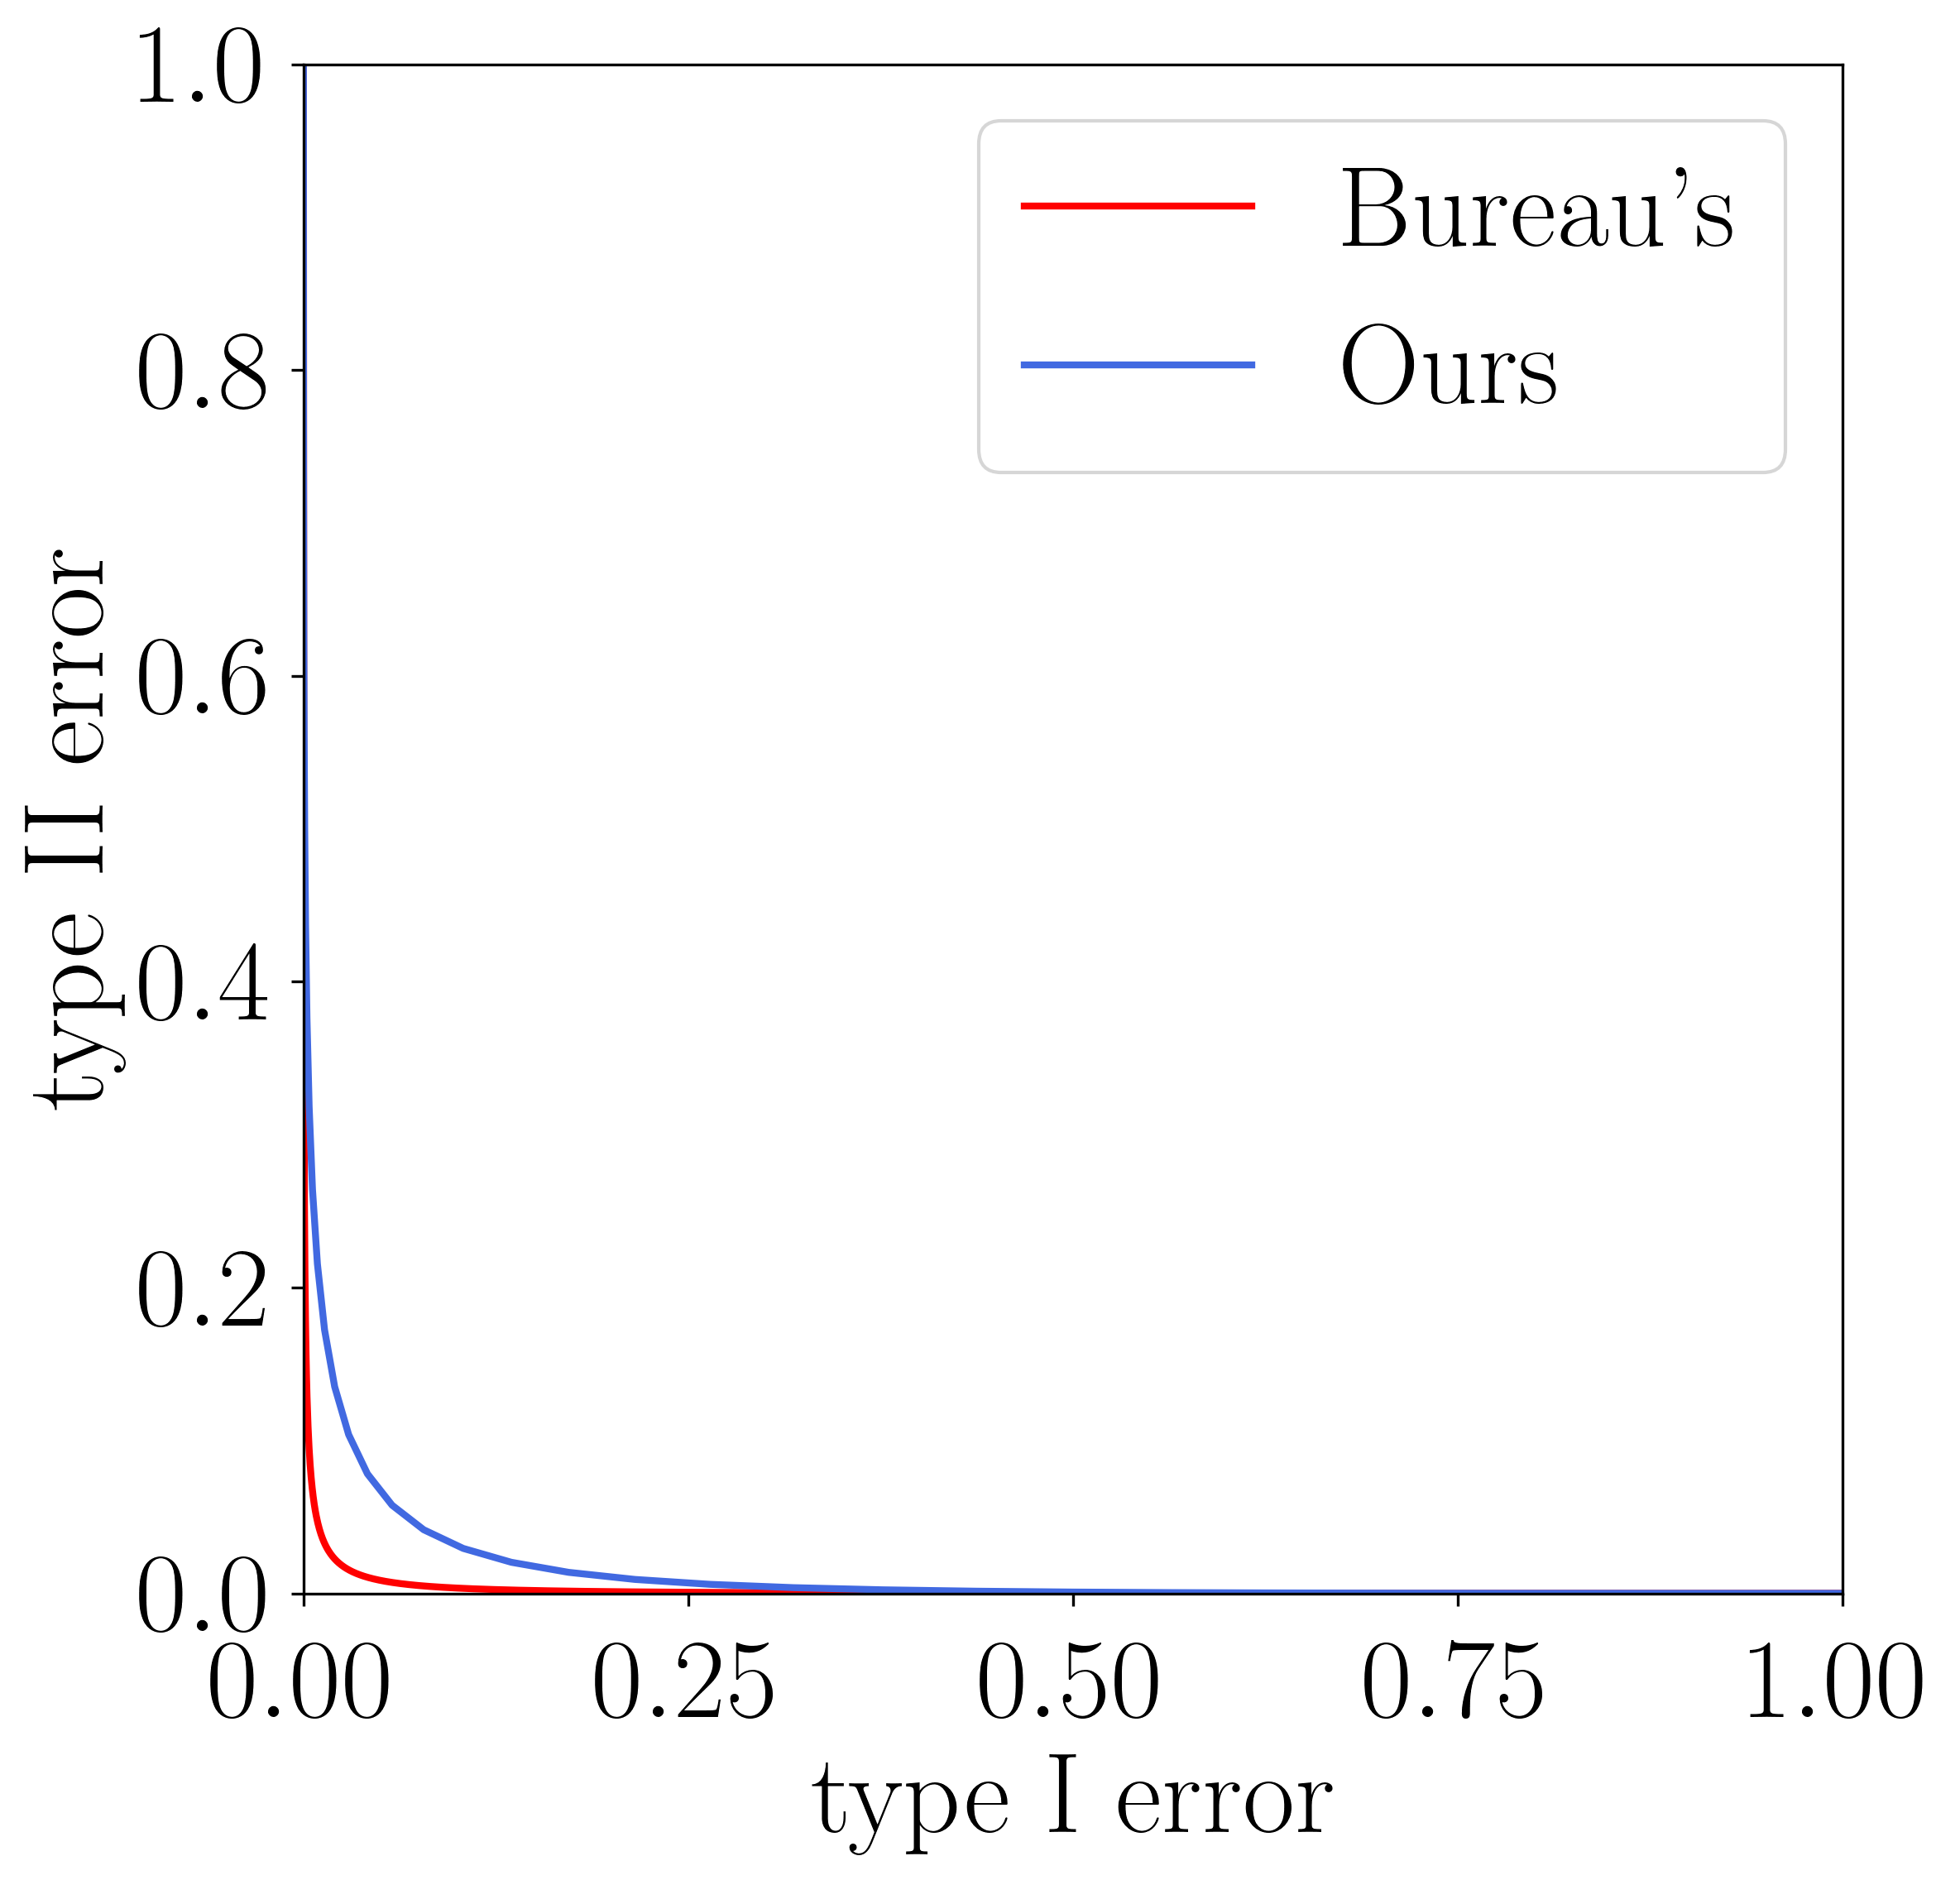

In [102]:
# Extract data
alpha = trade_off_curve['trade_off_alpha']
beta = trade_off_curve['trade_off_beta']

# Plotting
plt.figure()
plt.plot(alpha_bureau, beta_bureau, label="Bureau's", color='red', linewidth=2)
plt.plot(alpha, beta, label='Ours', color='royalblue', linewidth=2)
plt.xlabel(r'type I error')
plt.ylabel(r'type II error')
plt.tick_params(axis='x', pad=10)  # Add distance between x-axis tick labels and the axis
plt.tick_params(axis='y', pad=5)  # Add distance between x-axis tick labels and the axis

# plt.title(f"From Path {path_num_1} to {path_num_2}")
plt.legend(loc='upper right')
plt.ylim(0, 1)
plt.xlim(0, 1)  # Set the x-axis to start at 0

# Save the plot with dynamic filename
file_name = f"results_DHC_v0/trade_off_curve/figures/trade_off_curve_path_{path_num_1}_to_{path_num_2}.pdf"
plt.savefig(file_name, bbox_inches='tight')

# Display the plot
plt.show()

In [ ]:
end_time = time.time()
elapsed_time = (end_time - start_time)/3600
print(f"\n✅ Total runtime: {elapsed_time:.2f} Hours")